In [145]:
import astropy
import healpy as hp
import matplotlib.pyplot as plt 
import numpy as np
import shutil
from astropy.io import fits
import xml.dom.minidom
from astropy import units as u
from astropy.coordinates import SkyCoord
from healpy.newvisufunc import projview


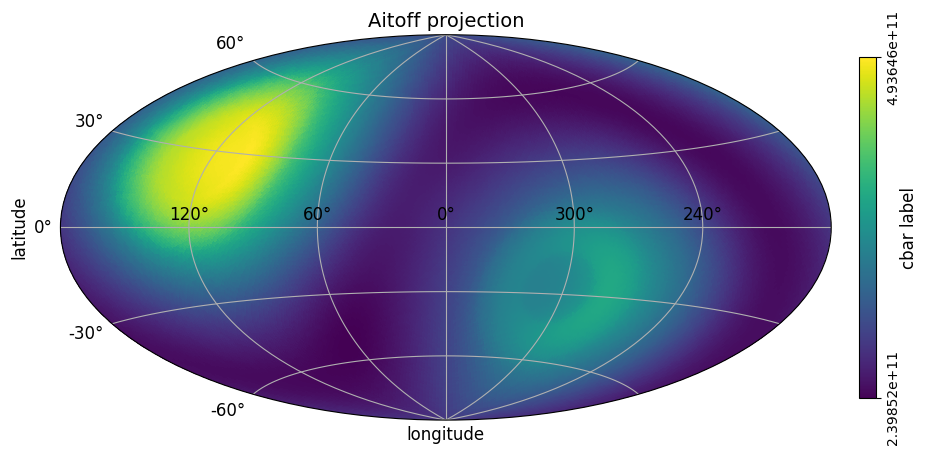

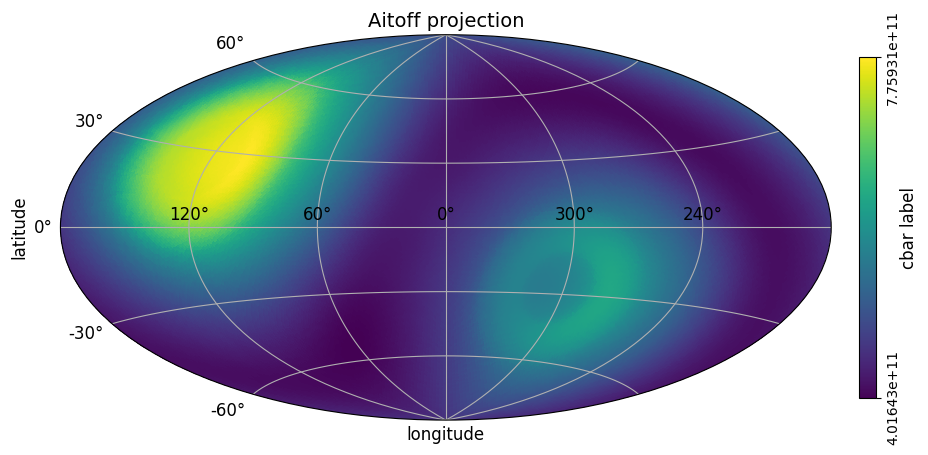

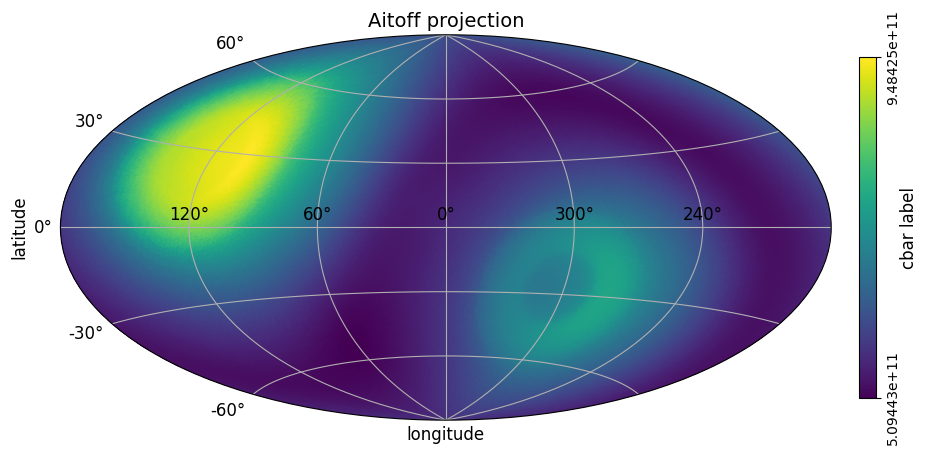

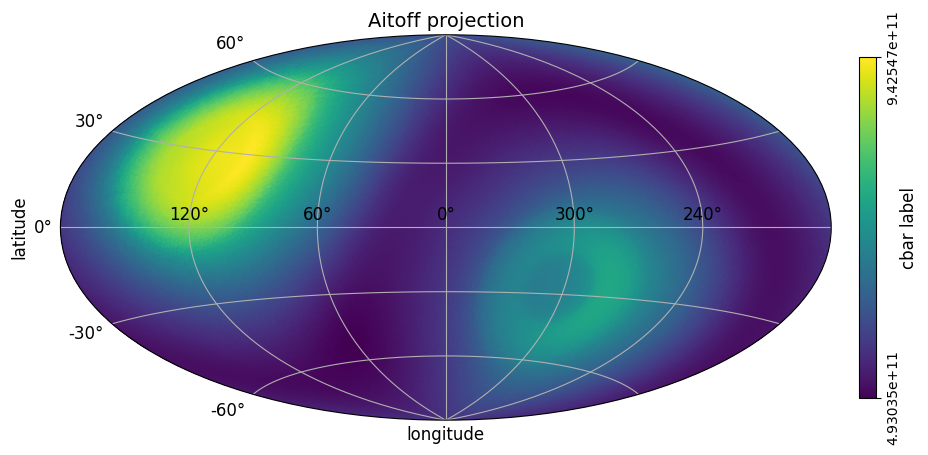

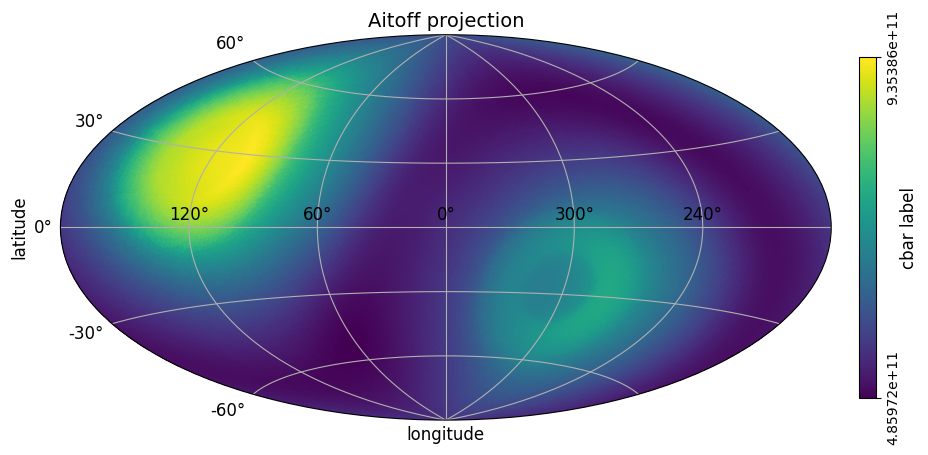

In [155]:
# Read binned exposure files

exposure_file = "/Volumes/T7/project_data/real_data/fermi_filtered_gti_exposure_map.fits"

with fits.open(exposure_file) as hdul:
    
    for bin in range(hdul[1].header["TFIELDS"] - 1):
    
        healpix_exposure_map = hp.read_map("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits", hdu="HPXEXPOSURES", field=bin)
    
        # hp.mollview(healpix_exposure_map)
        
        nside = hp.pixelfunc.get_nside(healpix_exposure_map)
        
        projview(
        healpix_exposure_map,
        coord=["G"],
        graticule=True,
        graticule_labels=True,
        unit="cbar label",
        xlabel="longitude",
        ylabel="latitude",
        cb_orientation="vertical",
        latitude_grid_spacing=30,
        projection_type="aitoff",
        title="Aitoff projection",
        )


In [161]:
# Read XML files to get latitude and longitude of each source (separate into AGN, pulsars, and background)

xml_file = "./simulated_data/sources.xml"

docs = xml.dom.minidom.parse(xml_file)

sources = docs.getElementsByTagName("source")

spatial_models = []

coordinates = []

# Parse XML
for source in sources:
    
    spatial_model = source.getElementsByTagName("spatialModel")[0]
        
    # for model in spatial_model:
    parameters = spatial_model.getElementsByTagName("parameter")
    
    coordinate = [0, 0]
    
    for param in parameters:
        name = param.getAttribute("name")
        
        if name == "RA":
            coordinate[0] = float(param.getAttribute("value"))
        else:
            coordinate[1] = float(param.getAttribute("value"))
    
    coordinates.append(coordinate)
    
# Have coordinates in format [RA, DEC] - need to convert them to Lat-lon

coordinates = [SkyCoord(ra=c[0]*u.degree, dec=c[1]*u.degree, frame='icrs').galactic for c in coordinates]

# Get coordinates into numpy array then separate into list of lats and lons
coordinates = np.array([[c.l.value, c.b.value] for c in coordinates]).T

latitudes = coordinates[0]
longitudes = coordinates[1]

pixels = hp.pixelfunc.ang2pix(nside=nside, theta=latitudes, phi=longitudes, nest=False, lonlat=True)


[45585 45585 26240 ... 24839 24568 24512]


1710.8939
855.0
0.003490658503988659


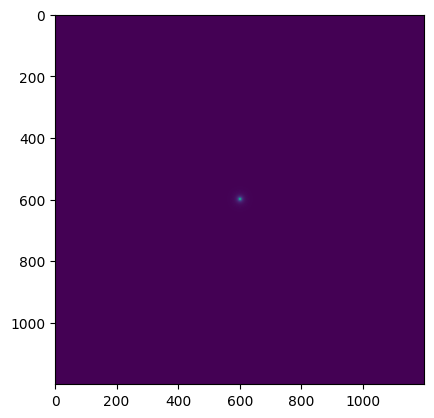

In [113]:
# Creating PSF for diffuse sources

roi_count_map = "/Volumes/T7/project_data/real_data/diffuse_psf_roi/count_map.fits"

with fits.open(roi_count_map) as hdul:

    counts = hdul[0].data
    
    plt.imshow(counts)
    
    midpoint = counts.shape[0] // 2
    
    x_axis = counts[midpoint]
    y_axis = counts[:, midpoint]
    
    values = (x_axis + y_axis) / 2
    
    max_value = np.max(values)
    
    print(max_value)
    print(max_value // 2)
    
    # Closest value to half the intensity - https://stackoverflow.com/questions/8914491/finding-the-nearest-value-and-return-the-index-of-array-in-python    
    half_intensity = (np.abs(values - (max_value // 2) )).argmin()
    
    # Find the difference between half way along the axis and centre - 0.05 degrees represented by 1 pixel. Multiply by two as it goes across the mean
    degrees_difference = np.abs(midpoint - half_intensity) * 0.05 * 2
    
    # Convert to radians
    degrees_difference *= (np.pi / 180)
    
    print(degrees_difference)












Filename: /Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      41   ()      
  1  HPXEXPOSURES    1 BinTableHDU     37   49152R x 7C   [D, D, D, D, D, D, D]   
  2  ENERGIES      1 BinTableHDU     13   7R x 1C   [1D]   
  3  GTI           1 BinTableHDU     18   98735R x 2C   [D, D]   
None
XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / 8-bit bytes                                    NAXIS   =                    2 / 2-dimensional binary table                     NAXIS1  =                   56 / width of table in bytes                        NAXIS2  =                49152 / number of rows in table                        PCOUNT  =                    0 / size of special data area                      GCOUNT  =                    1 / one data group (required keyword)              TFIELDS =                    7 

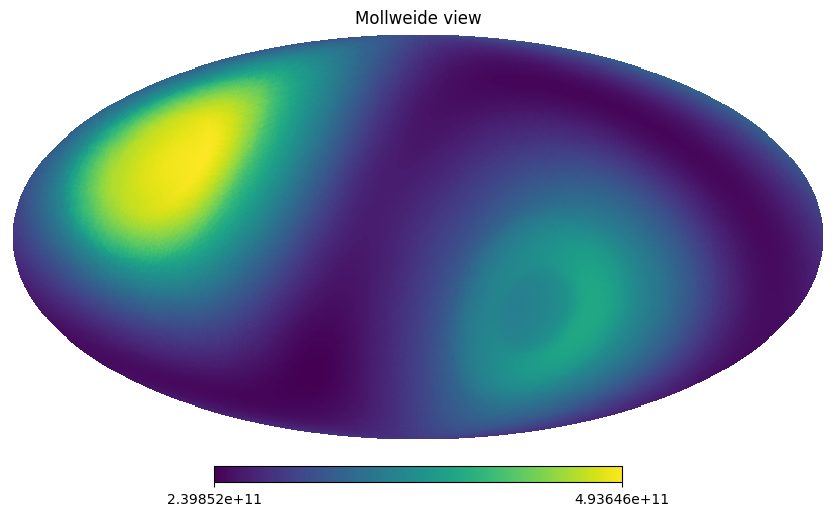

In [62]:
# Get number of bins

exposure_file = "/Volumes/T7/project_data/real_data/fermi_filtered_gti_exposure_map.fits"

with fits.open("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits") as hdul:
    
    print(hdul.info())
    
    print(hdul[1].header)
    
    hp.mollview(hp.read_map("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exp_from_bin.fits", hdu="HPXEXPOSURES"))
    
with fits.open(exposure_file) as hdul:
    
    binned_map_data = hdul[0].data
    num_bins = binned_map_data.shape[0]
    energy_bin_boundaries = binned_map_data[1].data
    
    # exposure_map_1, header = hp.fitsfunc.read_map(exposure_file, h=True, hdu=1, field=(2))
    # 
    # print(hdul[0].header)
    
    # 
    # hp.mollview(exposure_map_1, title='Original Fits Plot')
    
for k in range(num_bins - 1):
    
    new_file = "/Volumes/T7/project_data/real_data/fermi_exposure_map_bin_{}.fits".format(k)
    
    shutil.copyfile(exposure_file, new_file)
            
    # Create separate binned data files
    with fits.open(new_file, mode='update') as hdul:
        
        binned_map_data = hdul[0].data
        
        healpix_map = binned_map_data[k]
        
        hdul[0].data = hdul[0].data[k]
                
        hdul.flush()


AttributeError: 'numpy.ndarray' object has no attribute 'field'

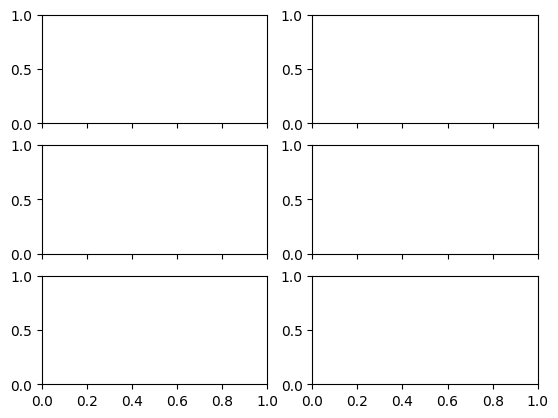

In [41]:
images = []

fig, ax = plt.subplots(nrows=3, ncols=2, sharex=True)

# exposure_map_1 = hp.fitsfunc.read_map("/Volumes/T7/data/sky_map_creation_data/fermi_filtered_exposure_map_bin_0.fits", hdu=1, nest=False)
for k in range(num_bins - 1):
    
    file_name = "/Volumes/T7/project_data/real_data/fermi_exposure_map_bin_{}.fits".format(k)
    
    exposure_map_1 = hp.fitsfunc.read_map(file_name, hdu=0, nest=False)
    # 
    # hp.mollview(exposure_map_1, title='Original Fits Plot')
    
    with fits.open(file_name, mode='update') as hdul:
        
        i = k // 2
        j = k % 2
        
        data = hdul[0].data
        
        print(hdul[0].header)
        
        energy_bin_boundaries = np.array([k[0] for k in np.array(hdul[1].data)])
                
        images.append(data)
                
    ax[i][j].imshow(data, cmap='gray')
    
    ax[i, j].set_title("{} to {} MeV".format(np.round(energy_bin_boundaries[k], 2), np.round(energy_bin_boundaries[k + 1], 2)))
    
fig.suptitle("Exposure Maps")

ax = np.ravel(ax)

for a in ax:
    a.set_axis_off()

fig.tight_layout()

plt.show()

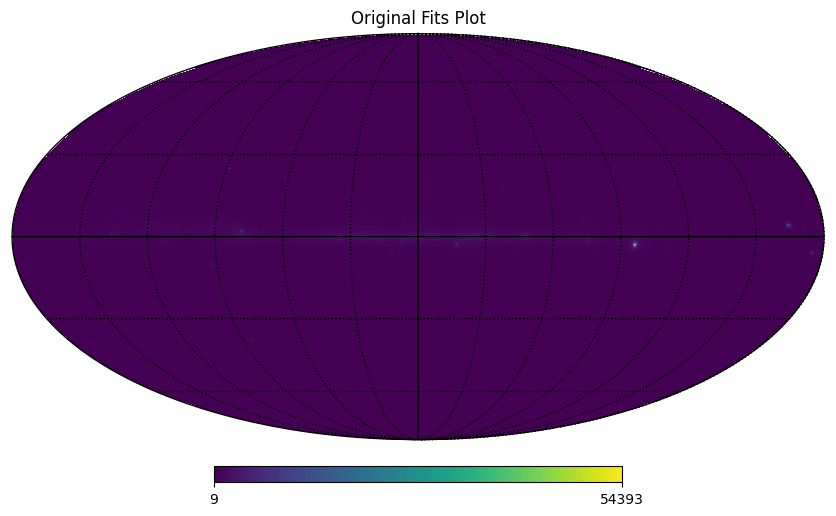

In [17]:
# hp.mollview(exposure_map, title='Original Fits Plot')
# hp.graticule()

In [ ]:
# REFERENCES

# Astropy Documentation - https://docs.astropy.org/en/stable/coordinates/skycoord.html